<a href="https://colab.research.google.com/github/Rasya-ai-web/Machine-Learning-Lab/blob/main/ML_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Synthetic Image Generation Using GAN

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Reshape, LeakyReLU
from tensorflow.keras.optimizers import Adam

In [ ]:
df = pd.read_csv("mnist_test.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)


X = df.iloc[:, 1:].values.astype("float32")


if X.shape[1] != 784:
    raise ValueError(
        "Dataset must contain 784 pixel columns. "
        "Please check your MNIST CSV file."
    )


X = (X - 127.5) / 127.5


X = X.reshape(-1, 28, 28, 1)

print("Images normalized successfully!")
print("Image shape:", X.shape)

Dataset loaded successfully!
Dataset shape: (10000, 785)
Images normalized successfully!
Image shape: (10000, 28, 28, 1)


In [ ]:

def build_generator():

    model = Sequential(name="Generator")

    model.add(Dense(128, input_shape=(100,)))
    model.add(LeakyReLU(negative_slope=0.2))

    model.add(Dense(256))
    model.add(LeakyReLU(negative_slope=0.2))

    model.add(Dense(784, activation="tanh"))

    model.add(Reshape((28, 28, 1)))

    return model

In [ ]:

def build_discriminator():

    model = Sequential(name="Discriminator")

    model.add(
        Flatten(input_shape=(28, 28, 1))
    )

    model.add(Dense(128))
    model.add(LeakyReLU(negative_slope=0.2))

    model.add(Dense(64))
    model.add(LeakyReLU(negative_slope=0.2))

    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=Adam(
            learning_rate=0.0002,
            beta_1=0.5
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
generator = build_generator()
discriminator = build_discriminator()

print("\nGenerator Summary:")
generator.summary()

print("\nDiscriminator Summary:")
discriminator.summary()


Generator Summary:


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_12 (LeakyReLU)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_13 (LeakyReLU)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 784)            │       201,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 247,440 (966.56 KB)

...

Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_14 (LeakyReLU)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_15 (LeakyReLU)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 108,801 (425.00 KB)

 Trainable params: 108,801 (425.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
discriminator.trainable = False

gan = Sequential(name="GAN")

gan.add(generator)
gan.add(discriminator)

gan.compile(
    optimizer=Adam(
        learning_rate=0.0002,
        beta_1=0.5
    ),
    loss="binary_crossentropy"
)

print("\nGAN created successfully!")



GAN created successfully!


In [ ]:
epochs = 200
batch_size = 128

for epoch in range(epochs):

    # -----------------------------
    # Train Discriminator
    # -----------------------------

    # Select real images
    index = np.random.randint(
        0,
        X.shape[0],
        batch_size
    )

    real_images = X[index]

    # Generate random noise
    noise = np.random.normal(
        0,
        1,
        (batch_size, 100)
    )

    # Generate fake images
    fake_images = generator.predict(
        noise,
        verbose=0
    )

    # Real = 1, Fake = 0
    real_labels = np.ones(
        (batch_size, 1)
    )

    fake_labels = np.zeros(
        (batch_size, 1)
    )

    # Enable discriminator training
    discriminator.trainable = True

    d_loss_real = discriminator.train_on_batch(
        real_images,
        real_labels
    )

    d_loss_fake = discriminator.train_on_batch(
        fake_images,
        fake_labels
    )

    d_loss = (
        np.array(d_loss_real) +
        np.array(d_loss_fake)
    ) / 2

    # -----------------------------
    # Train Generator
    # -----------------------------

    discriminator.trainable = False

    noise = np.random.normal(
        0,
        1,
        (batch_size, 100)
    )

    # Generator wants fake images
    # to be classified as real
    valid_labels = np.ones(
        (batch_size, 1)
    )

    g_loss = gan.train_on_batch(
        noise,
        valid_labels
    )

    print(
        "Epoch {}/{} | "
        "Discriminator Loss: {:.4f} | "
        "Generator Loss: {:.4f}".format(
            epoch + 1,
            epochs,
            float(d_loss[0]),
            float(g_loss)
        )
    )

Epoch 1/200 | Discriminator Loss: 0.4652 | Generator Loss: 0.9037
Epoch 2/200 | Discriminator Loss: 0.4669 | Generator Loss: 0.9023
Epoch 3/200 | Discriminator Loss: 0.4686 | Generator Loss: 0.9010
Epoch 4/200 | Discriminator Loss: 0.4704 | Generator Loss: 0.8994
Epoch 5/200 | Discriminator Loss: 0.4722 | Generator Loss: 0.8979
Epoch 6/200 | Discriminator Loss: 0.4740 | Generator Loss: 0.8966
Epoch 7/200 | Discriminator Loss: 0.4758 | Generator Loss: 0.8951
Epoch 8/200 | Discriminator Loss: 0.4776 | Generator Loss: 0.8933
Epoch 9/200 | Discriminator Loss: 0.4795 | Generator Loss: 0.8915
Epoch 10/200 | Discriminator Loss: 0.4817 | Generator Loss: 0.8896
Epoch 11/200 | Discriminator Loss: 0.4836 | Generator Loss: 0.8876
Epoch 12/200 | Discriminator Loss: 0.4854 | Generator Loss: 0.8857
Epoch 13/200 | Discriminator Loss: 0.4874 | Generator Loss: 0.8839
Epoch 14/200 | Discriminator Loss: 0.4895 | Generator Loss: 0.8818
Epoch 15/200 | Discriminator Loss: 0.4915 | Generator Loss: 0.8798
Epoc

In [ ]:
noise = np.random.normal(
    0,
    1,
    (10, 100)
)

generated_images = generator.predict(
    noise,
    verbose=0
)

# Convert -1 to 1 back to 0 to 1
generated_images = (
    generated_images + 1
) / 2

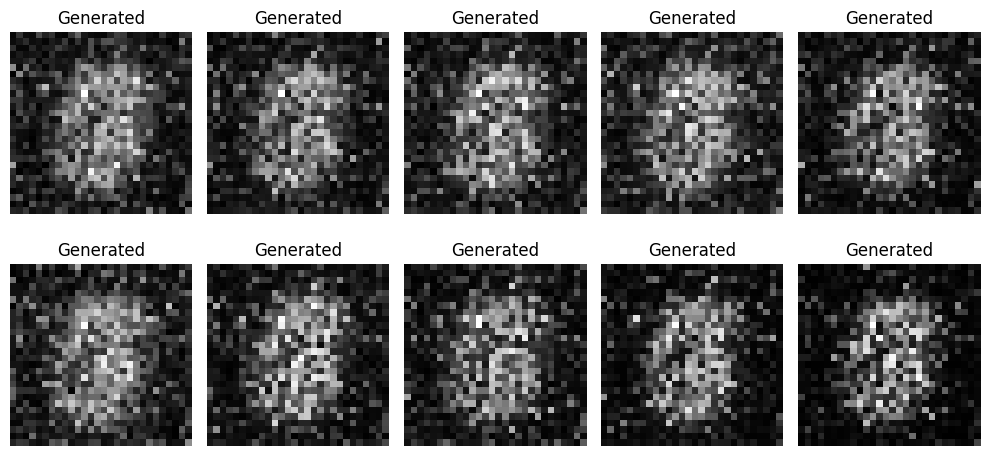

In [51]:
plt.figure(figsize=(10, 5))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        generated_images[i].reshape(28, 28),
        cmap="gray"
    )

    plt.axis("off")
    plt.title("Generated")

plt.tight_layout()
plt.show()

In [ ]:
print("\n----------------------------------")
print("GAN TRAINING COMPLETED")
print("----------------------------------")
print("Synthetic images generated: 10")
print("Image size: 28 x 28")
print("Dataset: MNIST")


----------------------------------
GAN TRAINING COMPLETED
----------------------------------
Synthetic images generated: 10
Image size: 28 x 28
Dataset: MNIST
